# Assignment 2 2AMM10 2023-2024

## Group: [Fill in your group name]
### Member 1: [Fill in your name]
### Member 2: [Fill in your name]
### Member 3: [Fill in your name]

We need to install some specific libraries. The cell below installs torch_geometric for torch 2.6.0+cu124. In case the current version of torch is different, check [here](https://pytorch-geometric.readthedocs.io/en/latest/install/installation.html) to see which versions (of both libraries) you should install. You might also need to install an old version of torch from [here](https://pytorch.org/get-started/previous-versions/)

**Note:** Do not install pyg_lib from the optional dependencies

In [1]:
%pip show torch

Name: torch
Version: 2.7.0+cu128
Summary: Tensors and Dynamic neural networks in Python with strong GPU acceleration
Home-page: https://pytorch.org/
Author: PyTorch Team
Author-email: packages@pytorch.org
License: BSD-3-Clause
Location: c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages
Requires: filelock, fsspec, jinja2, networkx, setuptools, sympy, typing-extensions
Required-by: openml-pytorch, pytorch-lightning, torchaudio, torchmetrics, torchvision
Note: you may need to restart the kernel to use updated packages.


In [2]:
%pip install rdkit
%pip install torch_geometric
%pip install torch_scatter torch_sparse torch_cluster torch_spline_conv -f https://data.pyg.org/whl/torch-2.6.0+cu124.html


Note: you may need to restart the kernel to use updated packages.


Looking in links: https://data.pyg.org/whl/torch-2.6.0+cu124.html
Note: you may need to restart the kernel to use updated packages.


In [3]:
import pickle
import numpy as np
from rdkit import Chem
from rdkit.Chem import Draw, AllChem
from rdkit import RDLogger
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch_geometric.data import Data, DataLoader
RDLogger.DisableLog('rdApp.*')
import matplotlib.pyplot as plt

c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\typing.py:86: UserWarning: An issue occurred while importing 'torch-scatter'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-scatter'. "
c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\typing.py:113: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(
c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\typing.py:124: UserWarning: An issue occurred while importing 'torch-sparse'. Disabling its usage. Stacktrace: [WinError 127] The specified procedure could not be found
  warnings.warn(f"An issue occurred while importing 'torch-sparse'. "


In [4]:
with open('pos_data.pkl', 'rb') as f:
    pos_data = pickle.load(f)

with open('type_data.pkl', 'rb') as f:
    type_data = pickle.load(f)

with open('smiles.pkl', 'rb') as f:
    smiles_data = pickle.load(f)

data_split = np.load('data_split.npz')

train_idxes = data_split['train_idx']
test_idxes = data_split['test_idx']

formation_energy = np.load('formation_energy.npz')

fe = formation_energy['y'] # normalized formation energy
mu = formation_energy['mu']
std = formation_energy['sigma']

In [5]:
# shapes of lists
print("Length of data")
print(f"pos_data: {len(pos_data)}, type_data: {len(type_data)}, smiles: {len(smiles_data)}")
print("Idxes")
print(f"train: {len(train_idxes)}, test: {len(test_idxes)}, sum: {len(train_idxes) + len(test_idxes)}")

Length of data
pos_data: 129012, type_data: 129012, smiles: 129012
Idxes
train: 119012, test: 10000, sum: 129012


In [6]:
def at_number_to_atom_name(at_number):
    if at_number == 6:
        return 'C'
    elif at_number == 1:
        return 'H'
    elif at_number == 7:
        return 'N'
    elif at_number == 8:
        return 'O'
    elif at_number == 9:
        return 'F'
    elif at_number == 16:
        return 'S'
    else:
        return 'Unknown'

def inspect_structure(idx):
    smile = smiles_data[idx]
    pos = pos_data[idx]
    typ = type_data[idx]

    header = f"{'Atom':^5}│{'Number':^6}│{'x':^10}│{'y':^10}│{'z':^10}"
    line   = "─────┼──────┼──────────┼──────────┼──────────"
    print(header)
    print(line)

    for atom_num, (x, y, z) in zip(typ, pos):
        atom_sym = at_number_to_atom_name(atom_num)
        print(f"{atom_sym:^5}│{atom_num:^6}│{x:>10.3f}│{y:>10.3f}│{z:>10.3f}")
    print("")
    print("")
    print(f'SMILE: {smile}')
    print("")
    print("")
    print(f'Formation Energy: {fe[idx]*std + mu:.3f}')
    print(f'Formation Energy (normalized): {fe[idx]:.5f}')
    mol = Chem.MolFromSmiles(smile)
    if mol:
        # RDKit prefers 2‑D coordinates for nice depictions
        Chem.AllChem.Compute2DCoords(mol)
        img = Draw.MolToImage(mol, size=(300, 300))

        # Display with matplotlib (works both in notebooks and scripts)
        plt.figure(figsize=(3, 3))
        plt.axis('off')
        plt.imshow(img)
        plt.show()

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │    -0.013│     1.086│     0.008
  H  │  1   │     0.002│    -0.006│     0.002
  H  │  1   │     1.012│     1.464│     0.000
  H  │  1   │    -0.541│     1.447│    -0.877
  H  │  1   │    -0.524│     1.438│     0.906


SMILE: C


Formation Energy: -17.172
Formation Energy (normalized): 5.72327


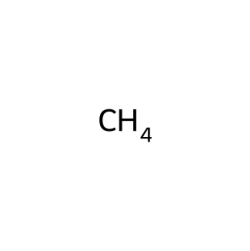

In [7]:
# methane
# Note how methane has a relatively high formation energy (compared to QM9)
# This correlates with lower thermodynamic stability and higher reactivity
# For example, methane readily burns in oxygen (CH₄ + 2O₂ → CO₂ + 2H₂O)
inspect_structure(0)

Atom │Number│    x     │    y     │    z     
─────┼──────┼──────────┼──────────┼──────────
  C  │  6   │     0.071│     1.477│    -0.034
  C  │  6   │     1.328│     0.673│     0.001
  N  │  7   │    -0.018│     0.019│    -0.005
  C  │  6   │    -0.247│    -0.610│    -1.344
  C  │  6   │     0.984│    -0.288│    -2.144
  C  │  6   │     1.652│    -0.439│    -3.310
  O  │  8   │     2.881│     0.118│    -3.208
  N  │  7   │     3.046│     0.668│    -1.926
  C  │  6   │     1.913│     0.416│    -1.332
  H  │  1   │    -0.272│     1.973│     0.870
  H  │  1   │    -0.159│     2.000│    -0.960
  H  │  1   │     1.924│     0.591│     0.902
  H  │  1   │    -0.374│    -1.688│    -1.196
  H  │  1   │    -1.177│    -0.225│    -1.775
  H  │  1   │     1.434│    -0.898│    -4.261


SMILE: c1onc2c1C[N@@H+]1C[C@H]21


Formation Energy: -66.733
Formation Energy (normalized): 0.91667


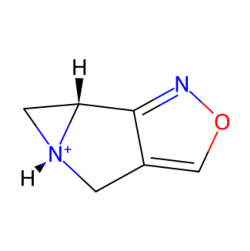

In [8]:
# random structure
inspect_structure(np.random.choice(range(len(smiles_data))))

## Task 1

In [ ]:
# Print example of pos, type data
print("pos", pos_data[0])
print("type", type_data[0])


def create_graph_data(pos, typ, fe):
    # Convert to tensor
    pos_tensor = torch.tensor(pos, dtype=torch.float)
    type_tensor = torch.tensor(typ, dtype=torch.long)
    fe_tensor = torch.tensor(fe*std + mu, dtype=torch.float)

    # Create edge index
    num_atoms = len(pos)
    edge_index = []
    for i in range(num_atoms):
        for j in range(num_atoms):
            if i != j:
                edge_index.append([i, j])    
    edge_index = torch.tensor(edge_index, dtype=torch.long).t().contiguous()
    x=type_tensor.unsqueeze(1).float()
    
    # Compute edge attributes (e.g., distances)
    row, col = edge_index
    edge_vec = pos_tensor[row] - pos_tensor[col]
    edge_attr = torch.norm(edge_vec, dim=1, keepdim=True)

    data = Data(x, pos=pos_tensor, edge_index=edge_index, edge_attr=edge_attr, y=fe_tensor)
    return data

# Create graph data for training and testing
train_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in train_idxes]
test_graph_data = [create_graph_data(pos_data[i], type_data[i], fe[i]) for i in test_idxes]

# Create validation set from 10% of training data
val_size = int(0.1 * len(train_graph_data))
train_graph_data, val_graph_data = train_graph_data[:-val_size], train_graph_data[-val_size:]

# Create DataLoader for training and testing
graph_train_loader = DataLoader(train_graph_data, batch_size=128, shuffle=True)
graph_val_loader = DataLoader(val_graph_data, batch_size=128, shuffle=False)
graph_test_loader = DataLoader(test_graph_data, batch_size=128, shuffle=False)

print(train_graph_data[0])

pos [[-1.2700e-02  1.0858e+00  8.0000e-03]
 [ 2.2000e-03 -6.0000e-03  2.0000e-03]
 [ 1.0117e+00  1.4638e+00  3.0000e-04]
 [-5.4080e-01  1.4475e+00 -8.7660e-01]
 [-5.2380e-01  1.4379e+00  9.0640e-01]]
type [6 1 1 1 1]
Data(x=[16, 1], edge_index=[2, 240], edge_attr=[240, 1], y=-68.8128433227539, pos=[16, 3])
Data(x=[9, 1], y=0.7149152, pos=[9, 3])


c:\Users\Anh Nguyen\.conda\envs\Base\Lib\site-packages\torch_geometric\deprecation.py:26: UserWarning: 'data.DataLoader' is deprecated, use 'loader.DataLoader' instead
  warnings.warn(out)


In [10]:
class Node_Embedding(nn.Module):
    def __init__ (self, node_feature_dim, node_embedding_dim):
        super(Node_Embedding, self).__init__()
        self.embedding_dim = node_embedding_dim
        self.feature_dim = node_feature_dim
        self.embedding = nn.Linear(node_feature_dim, node_embedding_dim)
    def forward(self, nodes):
        assert nodes.size(-1) == self.feature_dim, 'wrong input dimension of node features!'
        out = self.embedding(nodes)
        return out
    
# Message Passing Layer
class MP_layer(nn.Module):
    def __init__(self, hidden_dim, activation=nn.ReLU()):
        super(MP_layer, self).__init__()
        self.edge_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          activation
                                          )
        
        self.node_network = nn.Sequential(nn.Linear(2*hidden_dim, hidden_dim),
                                          activation,
                                          nn.Linear(hidden_dim, hidden_dim),
                                          )
        
    def forward(self, input_to_layer):
        node_tensor, edge_idx_tensor = input_to_layer
        edge_messages_input = torch.concat([node_tensor[edge_idx_tensor[0,:]], node_tensor[edge_idx_tensor[1,:]]], dim=-1)
        edge_messages_output = self.edge_network(edge_messages_input)
        
        node_agg_messages = torch.zeros(node_tensor.size(0), node_tensor.size(1)).to(node_tensor.device)
        node_agg_messages = node_agg_messages.scatter_add_(
            dim=0, index=edge_idx_tensor[1].unsqueeze(-1).expand(-1, node_tensor.size(1)), src=edge_messages_output
        )

        node_out = self.node_network(torch.cat([node_tensor, node_agg_messages], dim=-1))

        return node_out, edge_idx_tensor
    
# GNN
class FormationEnergyGNN(nn.Module):
    def __init__(self, node_feat_dim, hidden_dim, activation=nn.ReLU(), num_layers=3):
        super(FormationEnergyGNN, self).__init__()
        self.node_to_emb = Node_Embedding(node_feat_dim, hidden_dim)
        self.forward_net = nn.Sequential(
            *[MP_layer(hidden_dim, activation) for i in range(num_layers)]
        )
        self.to_pred = nn.Linear(hidden_dim, 1)

    def forward(self, x, edge_index, batch):
        x = self.node_to_emb(x)
        input_model = (x, edge_index)
        output_model = self.forward_net(input_model)
        x,_ = output_model
        
        out = torch.zeros(max(batch)+1, x.size(1)).to(x.device)
        idx_aggregate_graph = batch.unsqueeze(-1).expand(-1, x.size(1))

        out.scatter_add_(dim=0, index=idx_aggregate_graph, src=x)

        x = self.to_pred(out)
        return x
    
gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
gnn = gnn.to(device)

Using device: cuda


In [11]:
def train_gnn(model, train_loader, optimizer, criterion, device):
    model.train()
    for data in train_loader:
        data.to(device)
        optimizer.zero_grad()
        output = model(data.x, data.edge_index, data.batch)
        y = data.y.to(device)
        loss = criterion(output.squeeze(-1),y)
        loss.backward()
        optimizer.step()

def test_gnn(model, test_loader, criterion, device):
    model.eval()
    # Evaluate with R squared score
    total_loss = 0
    with torch.no_grad():
        for data in test_loader:
            data.to(device)
            output = model(data.x, data.edge_index, data.batch)
            y = data.y.to(device)
            loss = criterion(output.squeeze(-1), y)
            total_loss += loss.item()

    return total_loss / len(test_loader)

def r2_score(y_true, y_pred):
    ss_res = torch.sum((y_true - y_pred) ** 2)
    ss_tot = torch.sum((y_true - torch.mean(y_true)) ** 2)
    return 1 - (ss_res / ss_tot)

def train_task1():
    optimizer = torch.optim.Adam(gnn.parameters(), lr = 0.0001)
    criterion = nn.MSELoss()
    num_epochs = 10
    min_val_loss = float('inf')
    for epoch in range(num_epochs):
        train_gnn(gnn, graph_train_loader, optimizer, criterion, device)
        train_loss = test_gnn(gnn, graph_train_loader, criterion, device)
        val_loss = test_gnn(gnn, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(gnn.state_dict(), 'gnn_model_geometric.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

train_model = True
if train_model:
    train_task1()


Epoch 1/10, Train Loss: 11.3966, Val Loss: 11.5344
Epoch 2/10, Train Loss: 7.4972, Val Loss: 7.5539
Epoch 3/10, Train Loss: 5.2044, Val Loss: 5.2238
Epoch 4/10, Train Loss: 2.4961, Val Loss: 2.5111
Epoch 5/10, Train Loss: 3.4785, Val Loss: 3.5013
Epoch 6/10, Train Loss: 1.9399, Val Loss: 1.9580
Epoch 7/10, Train Loss: 2.3215, Val Loss: 2.3311
Epoch 8/10, Train Loss: 2.3904, Val Loss: 2.4079
Epoch 9/10, Train Loss: 1.7713, Val Loss: 1.7848
Epoch 10/10, Train Loss: 1.9773, Val Loss: 1.9916


In [12]:
# Evaluate on test set
y_true = []
y_pred = []
with torch.no_grad():
    gnn.eval()
    for data in graph_test_loader:
        data.to(device)
        output = gnn(data.x, data.edge_index, data.batch)
        y_true.append(data.y.cpu())
        y_pred.append(output.cpu())

y_true = torch.cat(y_true)
y_pred = torch.cat(y_pred).squeeze(-1)
print("y_pred", y_pred)
print("y_true", y_true)

r2 = r2_score(y_true, y_pred)
print(f'R squared score: {r2:.4f}')

y_pred tensor([-79.7211, -88.2280, -73.6680,  ..., -47.6204, -81.5805, -73.5438])
y_true tensor([-81.0877, -88.0048, -74.0629,  ..., -48.0841, -81.9360, -72.6332])
R squared score: 0.9821


## Task 2

In [13]:
task2_gnn = FormationEnergyGNN(node_feat_dim=1, hidden_dim=32, num_layers=5)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
task2_gnn = task2_gnn.to(device)

subset_sizes = [100,300,1000,3000,10000]

def train_task2(subset_size):
    optimizer = torch.optim.Adam(task2_gnn.parameters(), lr=0.0001)
    criterion = nn.MSELoss()
    num_epochs = 10
    min_val_loss = float('inf')
    
    subset_train_loader = DataLoader(train_graph_data[:subset_size], batch_size=128, shuffle=True)
    
    for epoch in range(num_epochs):
        train_gnn(task2_gnn, subset_train_loader, optimizer, criterion, device)
        train_loss = test_gnn(task2_gnn, subset_train_loader, criterion, device)
        val_loss = test_gnn(task2_gnn, graph_val_loader, criterion, device)
        if val_loss < min_val_loss:
            min_val_loss = val_loss
            torch.save(task2_gnn.state_dict(), f'task2_gnn_geometric_{subset_size}.pt')
        print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Val Loss: {val_loss:.4f}')

for size in subset_sizes:
    print(f'Training with subset size: {size}')
    train_task2(size)

def AULC(y_true, y_pred):
    # Calculate the Area Under the Loss Curve (AULC)
    sorted_indices = torch.argsort(y_true)
    y_true_sorted = y_true[sorted_indices]
    y_pred_sorted = y_pred[sorted_indices]
    
    loss = F.mse_loss(y_pred_sorted, y_true_sorted, reduction='none')
    # Calculate AULC
    aulc = torch.trapz(loss, y_true_sorted)
    return aulc.item()



Using device: cuda
Training with subset size: 100
Epoch 1/10, Train Loss: 6066.3784, Val Loss: 6039.3402
Epoch 2/10, Train Loss: 6006.0249, Val Loss: 5981.3603
Epoch 3/10, Train Loss: 5951.3257, Val Loss: 5928.6182
Epoch 4/10, Train Loss: 5905.8755, Val Loss: 5885.1337
Epoch 5/10, Train Loss: 5864.2251, Val Loss: 5844.4668
Epoch 6/10, Train Loss: 5824.2373, Val Loss: 5805.8954
Epoch 7/10, Train Loss: 5787.0562, Val Loss: 5769.3890
Epoch 8/10, Train Loss: 5749.0537, Val Loss: 5733.0888
Epoch 9/10, Train Loss: 5711.2637, Val Loss: 5697.2645
Epoch 10/10, Train Loss: 5674.6260, Val Loss: 5662.4915
Training with subset size: 300
Epoch 1/10, Train Loss: 5459.1556, Val Loss: 5544.1974
Epoch 2/10, Train Loss: 5352.5238, Val Loss: 5420.9374
Epoch 3/10, Train Loss: 5226.2417, Val Loss: 5265.9446
Epoch 4/10, Train Loss: 5058.3524, Val Loss: 5096.5200
Epoch 5/10, Train Loss: 4858.7244, Val Loss: 4879.0048
Epoch 6/10, Train Loss: 4501.0959, Val Loss: 4585.8696
Epoch 7/10, Train Loss: 4126.5309, Val

In [ ]:
# Evaluate on test set for each subset size
for size in subset_sizes:
    task2_gnn.load_state_dict(torch.load(f'task2_gnn_geometric_{size}.pt'))
    y_true = []
    y_pred = []
    with torch.no_grad():
        task2_gnn.eval()
        for data in graph_test_loader:
            data.to(device)
            output = task2_gnn(data.x, data.edge_index, data.batch)
            y_true.append(data.y.cpu())
            y_pred.append(output.cpu())

    y_true = torch.cat(y_true)
    y_pred = torch.cat(y_pred).squeeze(-1)
    

    r2 = r2_score(y_true, y_pred)
    aulc = AULC(y_true, y_pred)
    print(f'Subset size: {size}, R squared score: {r2:.4f}, AULC: {aulc:.4f}')

Subset size: 100, R squared score: -51.6770, AULC: 389944.4688
Subset size: 300, R squared score: -21.6519, AULC: 140791.8438
Subset size: 1000, R squared score: -0.3877, AULC: 37047.2109
Subset size: 3000, R squared score: 0.7947, AULC: 15356.7676
Subset size: 10000, R squared score: 0.9351, AULC: 3750.8850


## Task 3

In [15]:
def is_valid_smiles(smiles):
    if smiles is None:
        return False
    try:
        mol = Chem.MolFromSmiles(smiles)
        return mol is not None
    except:
        return False

def canonicalize(smiles):
    try:
        mol = Chem.MolFromSmiles(smiles)
        if mol:
            return Chem.MolToSmiles(mol, canonical=True)
        return 'None'
    except:
        return 'None'

In [16]:
canonicalize("COO"), canonicalize("O(C)O")

('COO', 'COO')

In [17]:
is_valid_smiles("COO"), is_valid_smiles("O(C)O"), is_valid_smiles("C##")

(True, True, False)